# Explore here

In [38]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

In [6]:
BASE_DIR = Path("../data/dataset/dogs-vs-cats")

all_imgs = list(BASE_DIR.glob("*.jpg"))

cats = [p for p in all_imgs if p.name.lower().startswith("cat.")]
dogs = [p for p in all_imgs if p.name.lower().startswith("dog.")]

print(f"Gatos: {len(cats)} | Perros: {len(dogs)}")

cats_train, cats_val = train_test_split(cats, test_size=0.2, random_state=42)
dogs_train, dogs_val = train_test_split(dogs, test_size=0.2, random_state=42)

for split in ["train", "val"]:
    (BASE_DIR / split / "cats").mkdir(parents=True, exist_ok=True)
    (BASE_DIR / split / "dogs").mkdir(parents=True, exist_ok=True)

def move(files, dst):
    for f in files:
        shutil.move(str(f), str(dst / f.name))

move(cats_train, BASE_DIR / "train" / "cats")
move(cats_val,   BASE_DIR / "val"   / "cats")
move(dogs_train, BASE_DIR / "train" / "dogs")
move(dogs_val,   BASE_DIR / "val"   / "dogs")

print("✔ Dataset dividido correctamente")



Gatos: 0 | Perros: 0


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [9]:

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42

base = Path("../data/dataset/dogs-vs-cats")

train_ds = tf.keras.utils.image_dataset_from_directory(
    base / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))


In [13]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(150,150,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 17, 17, 128)       

In [15]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [16]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10


625/625 [==============================] - 102s 150ms/step - loss: 0.6212 - accuracy: 0.6531 - val_loss: 0.5234 - val_accuracy: 0.7380
Epoch 2/10
625/625 [==============================] - 97s 155ms/step - loss: 0.4721 - accuracy: 0.7730 - val_loss: 0.4459 - val_accuracy: 0.7844
Epoch 3/10
625/625 [==============================] - 95s 152ms/step - loss: 0.3927 - accuracy: 0.8189 - val_loss: 0.4348 - val_accuracy: 0.7912
Epoch 4/10
625/625 [==============================] - 114s 182ms/step - loss: 0.3318 - accuracy: 0.8535 - val_loss: 0.4284 - val_accuracy: 0.8160
Epoch 5/10
625/625 [==============================] - 130s 208ms/step - loss: 0.2603 - accuracy: 0.8893 - val_loss: 0.3932 - val_accuracy: 0.8348
Epoch 6/10
625/625 [==============================] - 123s 197ms/step - loss: 0.1880 - accuracy: 0.9234 - val_loss: 0.4602 - val_accuracy: 0.8158
Epoch 7/10
625/625 [==============================] - 131s 210ms/step - loss: 0.1209 - accuracy: 0.9538 - val_loss: 0.5887 -

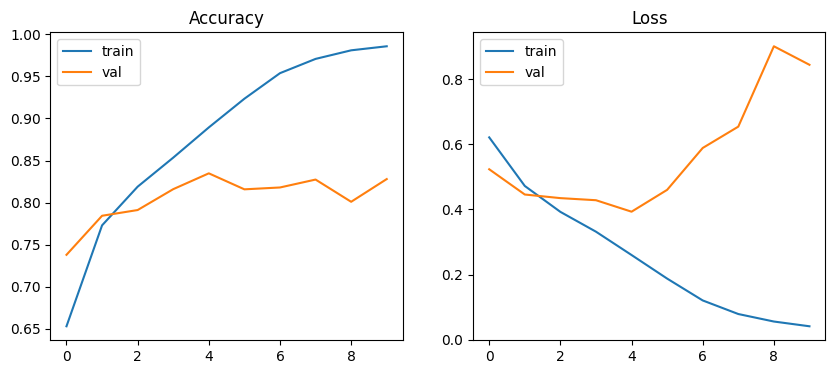

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.show()


In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [22]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])



In [24]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



In [25]:
history_aug = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)


Epoch 1/8
625/625 [==============================] - 158s 244ms/step - loss: 0.6758 - accuracy: 0.5843 - val_loss: 0.6288 - val_accuracy: 0.6562
Epoch 2/8
625/625 [==============================] - 151s 241ms/step - loss: 0.5858 - accuracy: 0.6912 - val_loss: 0.5257 - val_accuracy: 0.7470
Epoch 3/8
625/625 [==============================] - 155s 249ms/step - loss: 0.5090 - accuracy: 0.7473 - val_loss: 0.4961 - val_accuracy: 0.7632
Epoch 4/8
625/625 [==============================] - 178s 284ms/step - loss: 0.4758 - accuracy: 0.7700 - val_loss: 0.4478 - val_accuracy: 0.7924
Epoch 5/8
625/625 [==============================] - 201s 322ms/step - loss: 0.4463 - accuracy: 0.7890 - val_loss: 0.4207 - val_accuracy: 0.8064
Epoch 6/8
625/625 [==============================] - 200s 319ms/step - loss: 0.4241 - accuracy: 0.8021 - val_loss: 0.4244 - val_accuracy: 0.8090
Epoch 7/8
625/625 [==============================] - 170s 272ms/step - loss: 0.4017 - accuracy: 0.8184 - val_loss: 0.4411 - val_ac

In [29]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       0.85      0.80      0.82      2500
         Dog       0.81      0.85      0.83      2500

    accuracy                           0.83      5000
   macro avg       0.83      0.83      0.83      5000
weighted avg       0.83      0.83      0.83      5000



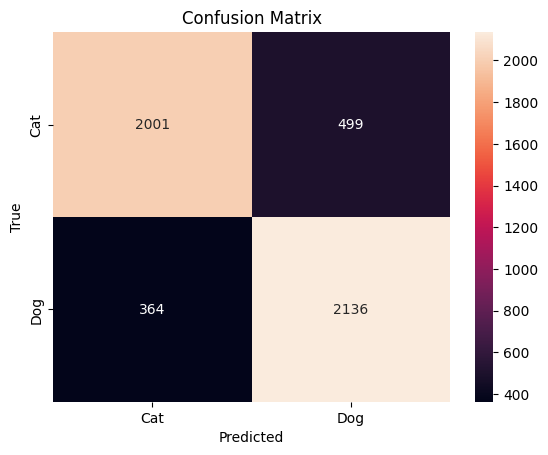

In [30]:

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [40]:
model.save("dogs_vs_cats_cnn.keras")

In [41]:
model = load_model("dogs_vs_cats_cnn.keras")
